In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [ ]:
# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

### Data Exploration

In [ ]:
# Display the first few rows of the dataset
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
#summarize statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
#Check for missing values
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


<Axes: xlabel='species'>

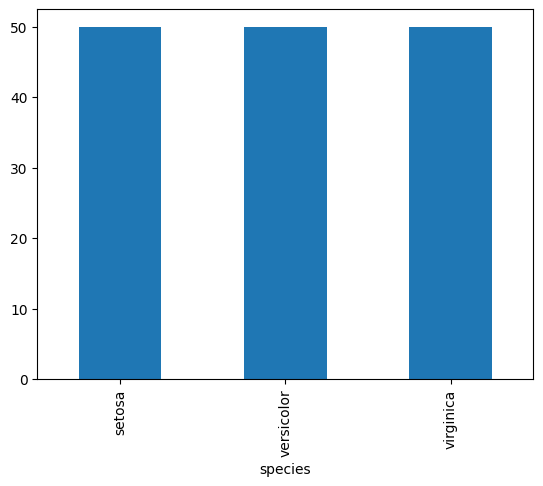

In [ ]:
#check the distribution
df['species'].value_counts().plot(kind='bar')

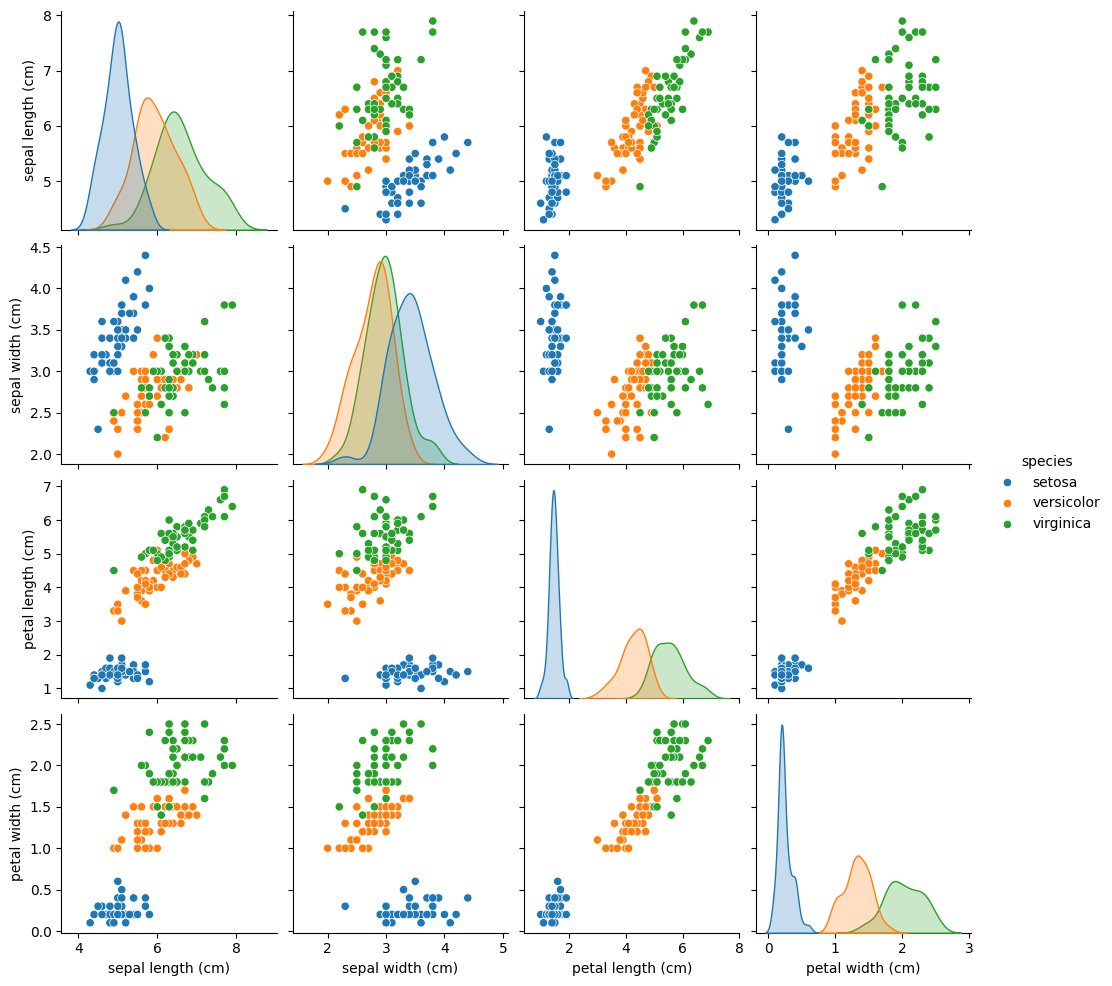

In [ ]:
# Pairplot to visualize the relationships between features
sns.pairplot(df, hue='species')
plt.show()

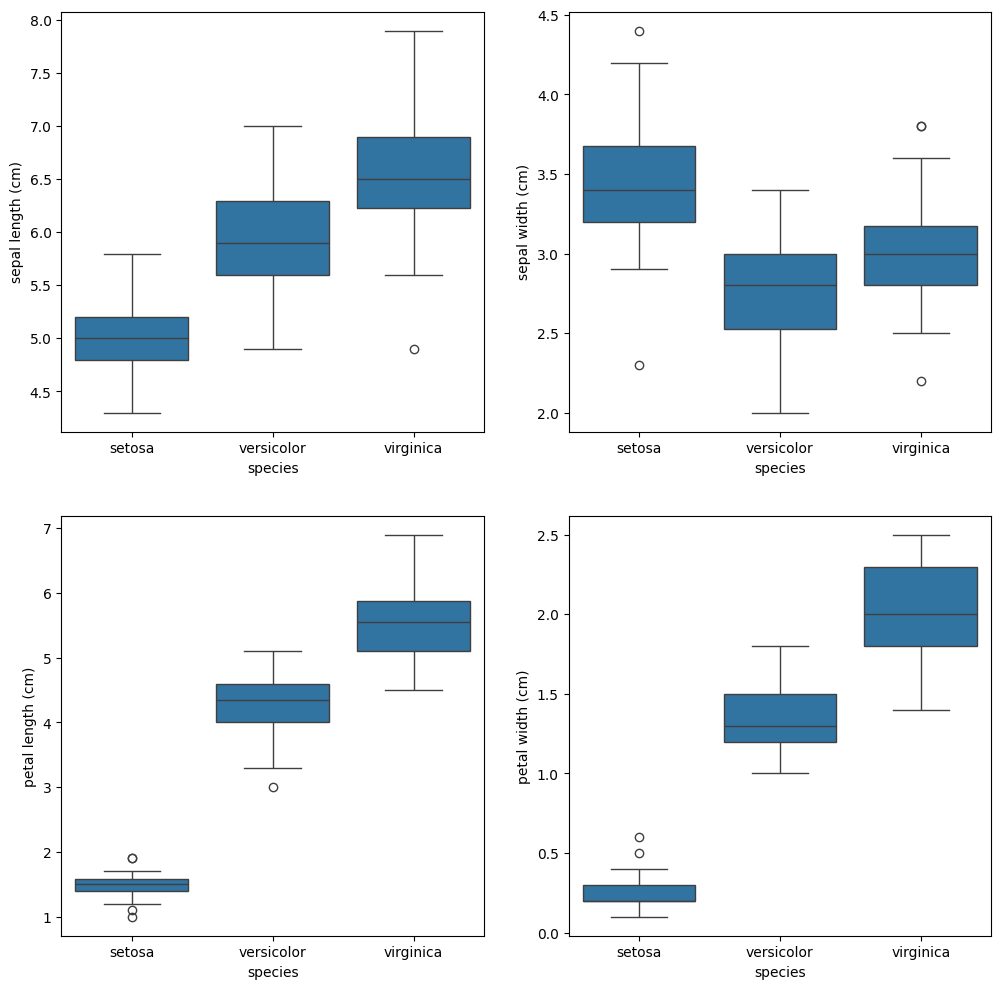

In [ ]:
# Box plots to examine the distribution and outliers
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
sns.boxplot(x='species', y='sepal length (cm)', data=df, ax=axs[0, 0])
sns.boxplot(x='species', y='sepal width (cm)', data=df, ax=axs[0, 1])
sns.boxplot(x='species', y='petal length (cm)', data=df, ax=axs[1, 0])
sns.boxplot(x='species', y='petal width (cm)', data=df, ax=axs[1, 1])
plt.show()

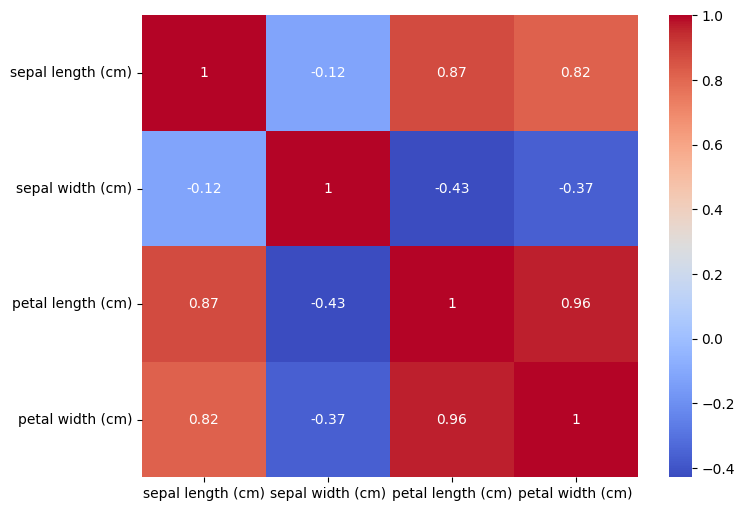

In [ ]:
# Heatmap to check the correlation between features
# Exclude the 'species' column for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])  # This ensures only numeric columns are included

# Heatmap to check the correlation between features
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

### Preparing data for train test split

In [ ]:
X = df[df.columns[:-1]]
y = df[df.columns[-1]]
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Data scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Training The Data**

In [ ]:
# Building the K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train_scaled, y_train.values.ravel())

KNeighborsClassifier(n_neighbors=2)

In [ ]:
# Predictions and evaluations
y_pred = knn.predict(X_test_scaled)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [ ]:
print(class_report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
print(conf_matrix)

[[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]


### Challenge

Download the dataset in the teams chat, notice that the file is in txt format. Set column names as follows:

col_names = ['Id', 'Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion',
             'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']
             
Perform data exploration as shown above and fit a KNN model to your data

In [ ]:
#load data and set column name
col_names = ['Id', 'Clump Thickness', 'Uniformity Cell Size', 'Uniformity Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']
df = pd.read_csv('breastcancer.txt', header=None, names=col_names)

In [ ]:
# Display the first few rows of the dataset
df.head()

,Id,Clump Thickness,Uniformity Cell Size,Uniformity Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
#summarize statistics
df.describe()

,Id,Clump Thickness,Uniformity Cell Size,Uniformity Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
#Check for missing values
missing_values = df.map(lambda x: x == '?').sum()
print(missing_values)

df.isnull().sum()

Id                             0
Clump Thickness                0
Uniformity Cell Size           0
Uniformity Cell Shape          0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


,0
Id,0
Clump Thickness,0
Uniformity Cell Size,0
Uniformity Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


<Axes: xlabel='Class'>

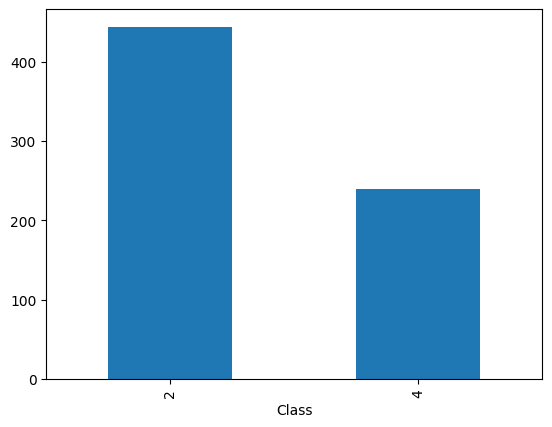

In [ ]:
#check the distribution
df['Class'].value_counts().plot(kind='bar')

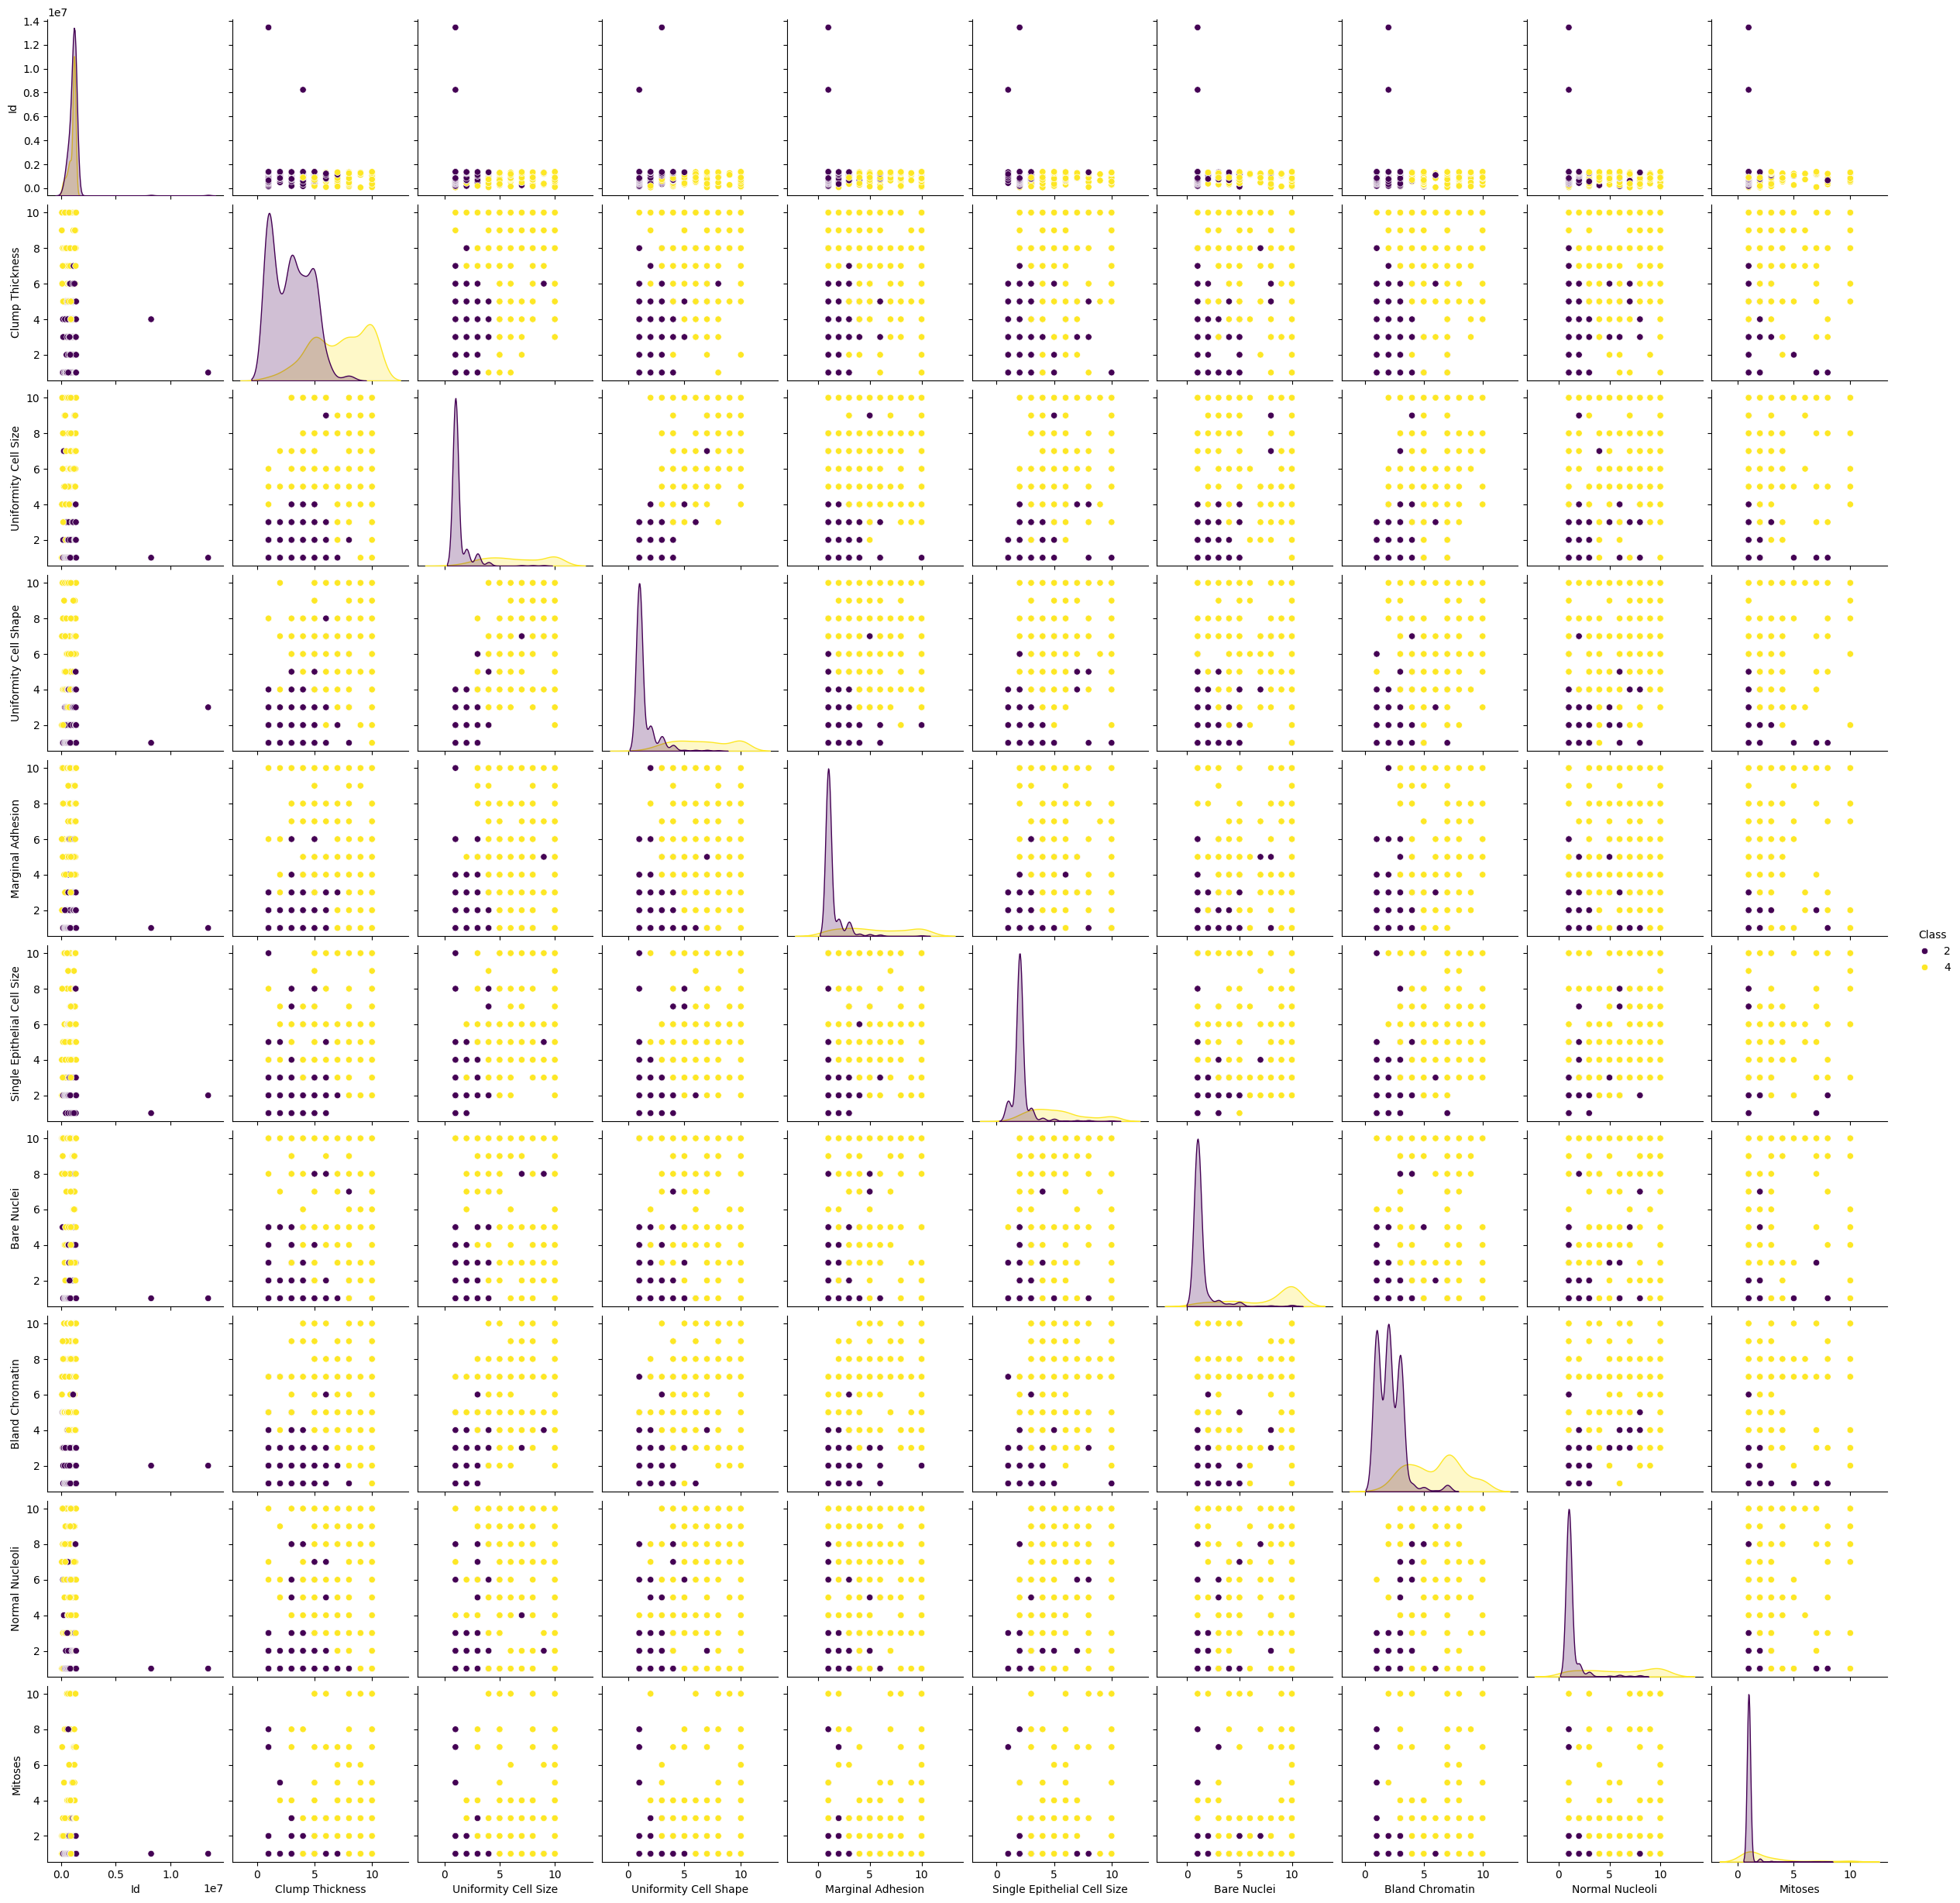

In [ ]:
# Pairplot to visualize the relationships between features
sns.pairplot(df, hue='Class', palette='viridis')
plt.show()

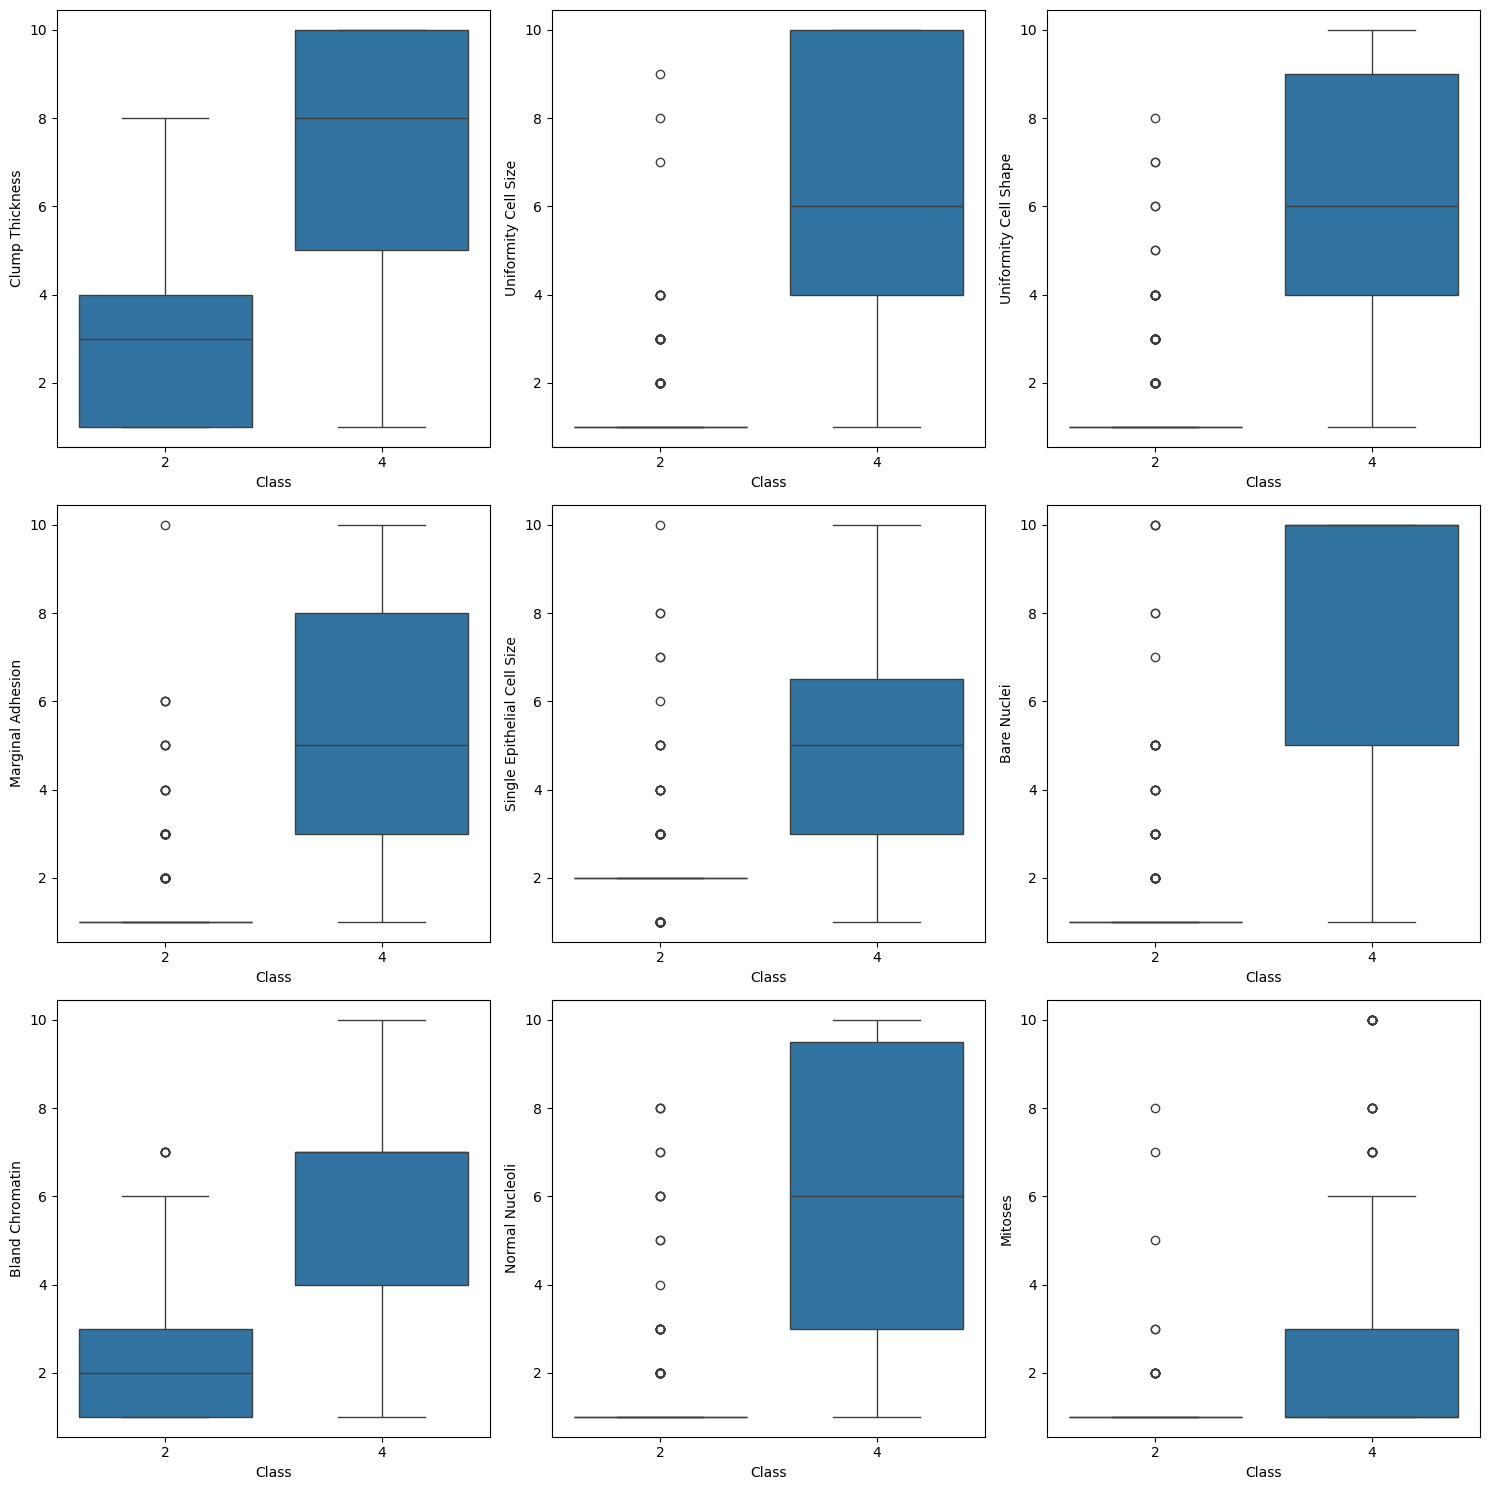

In [ ]:
# Box plots to examine the distribution and outliers
col_names = ['Clump Thickness', 'Uniformity Cell Size', 'Uniformity Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses']

fig, axs = plt.subplots(3, 3, figsize=(15, 15))
sns.boxplot(x='Class', y=col_names[0], data=df, ax=axs[0, 0])
sns.boxplot(x='Class', y=col_names[1], data=df, ax=axs[0, 1])
sns.boxplot(x='Class', y=col_names[2], data=df, ax=axs[0, 2])
sns.boxplot(x='Class', y=col_names[3], data=df, ax=axs[1, 0])
sns.boxplot(x='Class', y=col_names[4], data=df, ax=axs[1, 1])
sns.boxplot(x='Class', y=col_names[5], data=df, ax=axs[1, 2])
sns.boxplot(x='Class', y=col_names[6], data=df, ax=axs[2, 0])
sns.boxplot(x='Class', y=col_names[7], data=df, ax=axs[2, 1])
sns.boxplot(x='Class', y=col_names[8], data=df, ax=axs[2, 2])

plt.tight_layout()
plt.show()

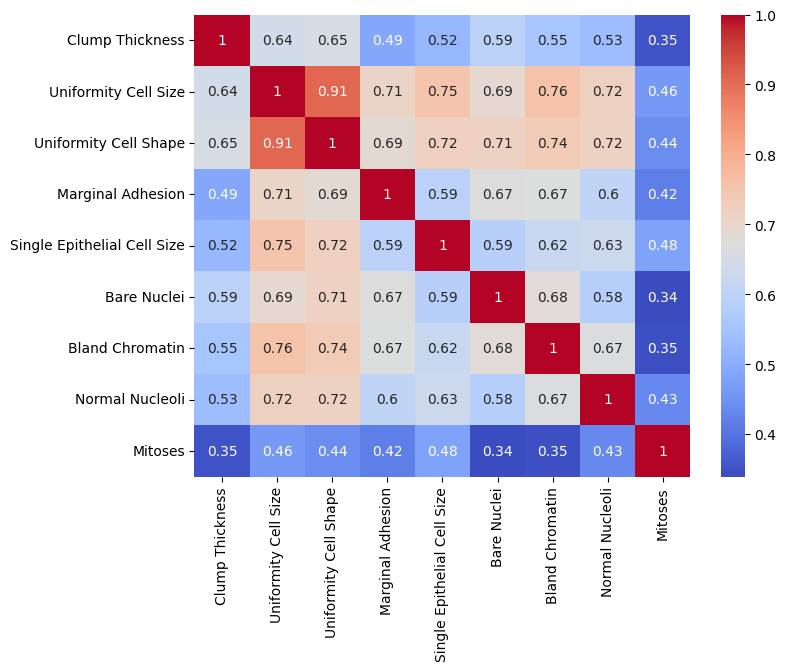

In [ ]:
# Heatmap to check the correlation between features
# Exclude the 'Class' and 'Id' column for correlation matrix
numeric_df = df.iloc[:, 1:-1].select_dtypes(include=[np.number])  # This ensures 'Class' and 'Id' columns are not included

# Heatmap to check the correlation between features
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
X = df[df.columns[1:-1]]
y = df[df.columns[-1]]
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Data scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Building the K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train_scaled, y_train.values.ravel())

KNeighborsClassifier(n_neighbors=2)

In [ ]:
# Predictions and evaluations
y_pred = knn.predict(X_test_scaled)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [ ]:
print(class_report)

              precision    recall  f1-score   support

           2       0.91      0.98      0.94       127
           4       0.97      0.83      0.90        78

    accuracy                           0.93       205
   macro avg       0.94      0.91      0.92       205
weighted avg       0.93      0.93      0.93       205



In [ ]:
print(conf_matrix)

[[125   2]
 [ 13  65]]
